In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
from google.colab import files

uploaded = files.upload()

print("Загружено файлов:", len(uploaded))
print(list(uploaded.keys()))

Saving closed_1.csv to closed_1.csv
Saving closed_2.csv to closed_2.csv
Saving closed_3.csv to closed_3.csv
Saving closed_4.csv to closed_4.csv
Saving closed_5.csv to closed_5.csv
Saving closed_6.csv to closed_6.csv
Saving closed_7.csv to closed_7.csv
Saving closed_8.csv to closed_8.csv
Saving closed_9.csv to closed_9.csv
Saving closed_10.csv to closed_10.csv
Saving opened_1.csv to opened_1.csv
Saving opened_2.csv to opened_2.csv
Saving opened_3.csv to opened_3.csv
Saving opened_4.csv to opened_4.csv
Saving opened_5.csv to opened_5.csv
Saving opened_6.csv to opened_6.csv
Saving opened_7.csv to opened_7.csv
Saving opened_8.csv to opened_8.csv
Saving opened_9.csv to opened_9.csv
Загружено файлов: 19
['closed_1.csv', 'closed_2.csv', 'closed_3.csv', 'closed_4.csv', 'closed_5.csv', 'closed_6.csv', 'closed_7.csv', 'closed_8.csv', 'closed_9.csv', 'closed_10.csv', 'opened_1.csv', 'opened_2.csv', 'opened_3.csv', 'opened_4.csv', 'opened_5.csv', 'opened_6.csv', 'opened_7.csv', 'opened_8.csv', 'op

In [3]:
open_files = []
closed_files = []

for name in uploaded.keys():

    if "opened" in name or "open" in name:
        open_files.append(name)

    if "closed" in name:
        closed_files.append(name)

print("open files:", len(open_files))
print("closed files:", len(closed_files))

print("\nOPEN:")
print(open_files)

print("\nCLOSED:")
print(closed_files)

open files: 9
closed files: 10

OPEN:
['opened_1.csv', 'opened_2.csv', 'opened_3.csv', 'opened_4.csv', 'opened_5.csv', 'opened_6.csv', 'opened_7.csv', 'opened_8.csv', 'opened_9.csv']

CLOSED:
['closed_1.csv', 'closed_2.csv', 'closed_3.csv', 'closed_4.csv', 'closed_5.csv', 'closed_6.csv', 'closed_7.csv', 'closed_8.csv', 'closed_9.csv', 'closed_10.csv']


In [4]:
def read_eeg(file_name):
    df = pd.read_csv(file_name, sep=';', decimal=',')
    df.columns = ['time', 'EEG']
    return df

test_open = read_eeg(open_files[0])
test_closed = read_eeg(closed_files[0])

print("OPEN shape:", test_open.shape)
print("CLOSED shape:", test_closed.shape)

display(test_open.head())
display(test_closed.head())

OPEN shape: (3456, 2)
CLOSED shape: (2598, 2)


,time,EEG
0,0.000,488.376550
1,0.005,490.944269
2,0.010,491.067628
3,0.015,490.392502
4,0.020,489.417472


,time,EEG
0,0.000,533.588568
1,0.005,515.315695
2,0.010,502.865219
3,0.015,498.816492
4,0.020,504.008028


In [5]:
FS = 200

def extract_features(signal):

    signal = signal - np.mean(signal)

    f, pxx = welch(signal, fs=FS, nperseg=512)

    delta = np.mean(pxx[(f >= 1) & (f < 4)])
    theta = np.mean(pxx[(f >= 4) & (f < 8)])
    alpha = np.mean(pxx[(f >= 8) & (f < 12)])
    beta  = np.mean(pxx[(f >= 12) & (f < 30)])

    return [delta, theta, alpha, beta]

In [6]:
X = []
y = []

# open = 0
for file in open_files:

    df = read_eeg(file)
    signal = df['EEG'].values

    features = extract_features(signal)

    X.append(features)
    y.append(0)

# closed = 1
for file in closed_files:

    df = read_eeg(file)
    signal = df['EEG'].values

    features = extract_features(signal)

    X.append(features)
    y.append(1)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nПример признаков:")
print(X[:3])

X shape: (19, 4)
y shape: (19,)

Пример признаков:
[[160.31995057 236.38610353 234.15154999  27.29843027]
 [  8.21119448   4.89091459   4.51033532  18.63030569]
 [264.66644584 230.46377091   7.35446066   1.10285834]]


/tmp/ipykernel_1389/296775195.py:7: UserWarning: nperseg=512 is greater than signal length max(len(x), len(y)) = 204, using nperseg = 204
  f, pxx = welch(signal, fs=FS, nperseg=512)


In [7]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

print("Accuracy:", accuracy_score(ytest, pred))

print("\nClassification report:")
print(classification_report(ytest, pred))

print("\nConfusion matrix:")
print(confusion_matrix(ytest, pred))

Accuracy: 0.5

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6


Confusion matrix:
[[0 3]
 [0 3]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
FS = 200
WINDOW = 400   # 2 секунды
STEP = 200     # 1 секунда

def extract_features_from_windows(signal, label):
    X_list = []
    y_list = []

    signal = signal - np.mean(signal)

    for start in range(0, len(signal) - WINDOW + 1, STEP):
        segment = signal[start:start + WINDOW]

        f, pxx = welch(segment, fs=FS, nperseg=400)

        delta = np.mean(pxx[(f >= 1) & (f < 4)])
        theta = np.mean(pxx[(f >= 4) & (f < 8)])
        alpha = np.mean(pxx[(f >= 8) & (f < 12)])
        beta  = np.mean(pxx[(f >= 12) & (f < 30)])

        X_list.append([delta, theta, alpha, beta])
        y_list.append(label)

    return X_list, y_list

In [9]:
X_win = []
y_win = []

# open = 0
for file in open_files:
    df = read_eeg(file)
    signal = df['EEG'].values

    x_part, y_part = extract_features_from_windows(signal, 0)

    X_win.extend(x_part)
    y_win.extend(y_part)

# closed = 1
for file in closed_files:
    df = read_eeg(file)
    signal = df['EEG'].values

    x_part, y_part = extract_features_from_windows(signal, 1)

    X_win.extend(x_part)
    y_win.extend(y_part)

X_win = np.array(X_win)
y_win = np.array(y_win)

print("X_win shape:", X_win.shape)
print("y_win shape:", y_win.shape)
print("Класс 0 (open):", np.sum(y_win == 0))
print("Класс 1 (closed):", np.sum(y_win == 1))

X_win shape: (231, 4)
y_win shape: (231,)
Класс 0 (open): 125
Класс 1 (closed): 106


In [10]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X_win,
    y_win,
    test_size=0.3,
    random_state=42,
    stratify=y_win
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

print("Accuracy:", accuracy_score(ytest, pred))
print("\nClassification report:")
print(classification_report(ytest, pred))
print("\nConfusion matrix:")
print(confusion_matrix(ytest, pred))

Accuracy: 0.9142857142857143

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93        38
           1       0.96      0.84      0.90        32

    accuracy                           0.91        70
   macro avg       0.92      0.91      0.91        70
weighted avg       0.92      0.91      0.91        70


Confusion matrix:
[[37  1]
 [ 5 27]]


delta : 0.192
theta : 0.219
alpha : 0.161
beta : 0.429


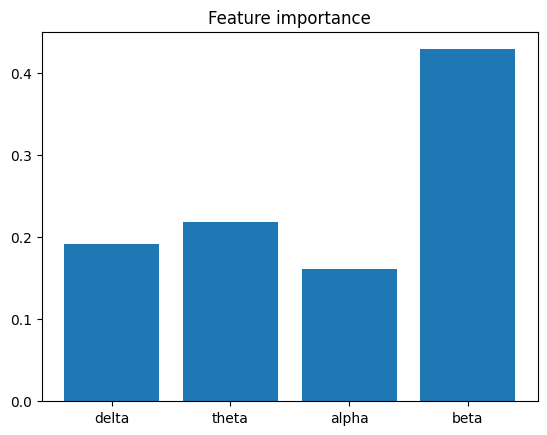

In [11]:
features = ['delta','theta','alpha','beta']

importance = model.feature_importances_

for f,i in zip(features,importance):
    print(f,":",round(i,3))

plt.bar(features,importance)
plt.title("Feature importance")
plt.show()

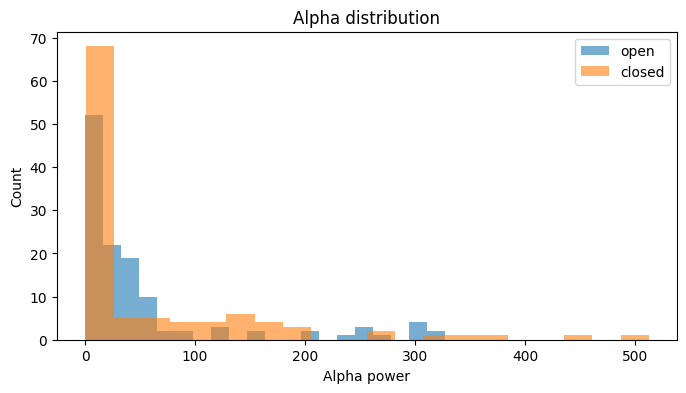

In [12]:
alpha_open = X_win[y_win == 0][:,2]
alpha_closed = X_win[y_win == 1][:,2]

plt.figure(figsize=(8,4))

plt.hist(alpha_open, bins=20, alpha=0.6, label="open")
plt.hist(alpha_closed, bins=20, alpha=0.6, label="closed")

plt.xlabel("Alpha power")
plt.ylabel("Count")
plt.title("Alpha distribution")
plt.legend()

plt.show()